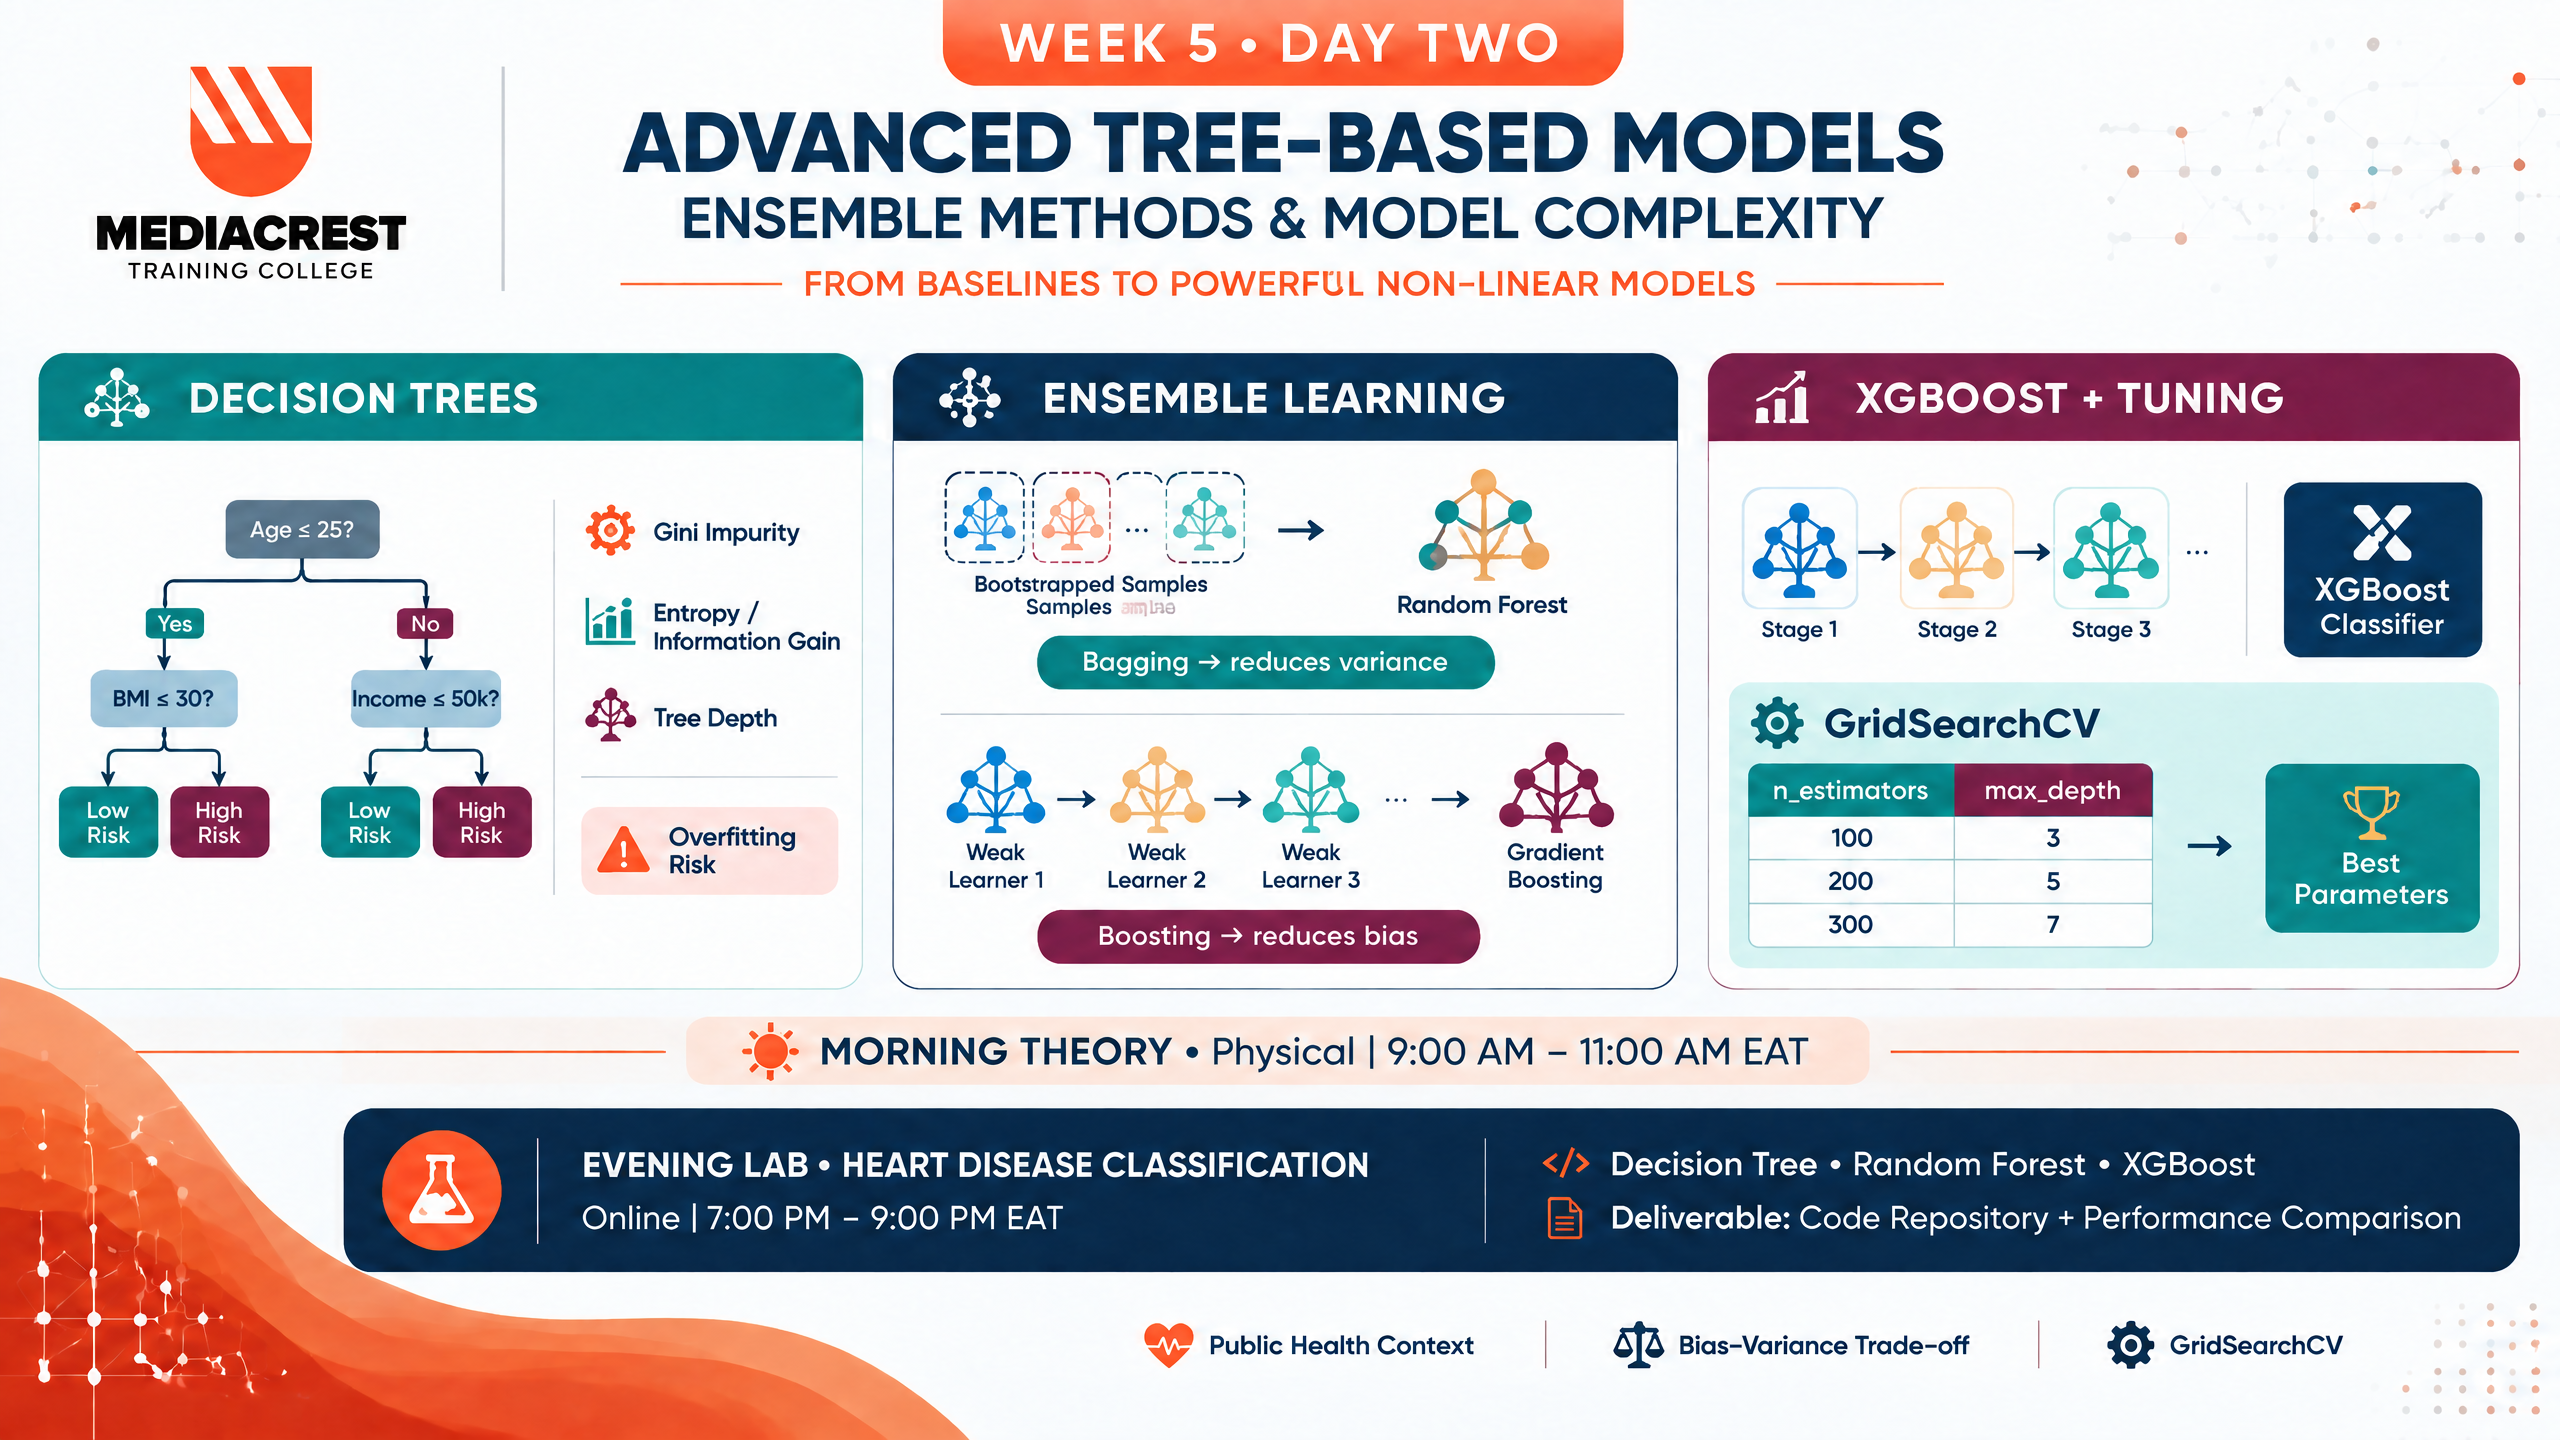

## **Machine Learning II: Classification Foundations & Ensemble Learning Models**
**Week 5, Day 3:** Transitioning to Classification, Ensemble Learning Models

## **MACHINE LEARNING**

Machine Learning (ML) is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed. Instead of following fixed rules, machine learning algorithms improve their performance as they are exposed to more data.

### **Why Machine Learning?**

Machine learning is used to analyze large amounts of data, uncover hidden patterns, make predictions, automate decision-making, and improve accuracy in solving real-world problems.

### **Branches of Machine Learning**

**Supervised Learning** uses labeled data, where the correct output is already known. It is mainly used for **classification** (predicting categories such as spam or not spam) and **regression** (predicting continuous values such as house prices).

**Unsupervised Learning** uses unlabeled data to discover hidden structures or patterns. It is commonly applied in clustering, customer segmentation, and association rule mining.

**Semi-Supervised Learning** combines a small amount of labeled data with a large amount of unlabeled data to improve model performance, especially when labeling data is expensive.

**Reinforcement Learning** enables an agent to learn by interacting with its environment and receiving rewards or penalties. It is widely used in robotics, autonomous vehicles, and game-playing systems.

### **Types of Machine Learning Problems**

Machine learning problems are generally classified into **classification**, **regression**, **clustering**, and **anomaly detection**. Classification predicts categories, regression predicts numerical values, clustering groups similar observations, while anomaly detection identifies unusual or suspicious patterns.

### **Applications of Machine Learning**

Machine learning has applications across many fields. In healthcare, it supports disease diagnosis and medical image analysis. In finance, it is used for fraud detection and credit scoring. Businesses use it for customer segmentation, sales forecasting, and recommendation systems. Other applications include agriculture, education, transportation, manufacturing, cybersecurity, and environmental monitoring.

### **Advantages**

Machine learning can process large datasets efficiently, identify complex patterns, improve prediction accuracy, automate repetitive tasks, and support data-driven decision-making.

### **Challenges**

Despite its benefits, machine learning requires high-quality data, significant computational resources, and careful model selection. Poor data quality, overfitting, and biased datasets can reduce model performance.

### **Summary**

Machine learning is a powerful field of Artificial Intelligence that allows computers to learn from data and improve their predictions over time. Its four major branches—supervised, unsupervised, semi-supervised, and reinforcement learning—provide solutions to a wide range of prediction, classification, and pattern recognition problems across numerous industries.

### **STAGE 1: PROBLEM FORMULATION**
Clinical Objective: Predict presence of Atherosclerotic Heart Disease (AHD) to enable 
early intervention and risk stratification.

Target Variable: 'AHD' (Binary: 0 = No Disease, 1 = Disease Present)

Real-World Implications:
- False Negatives: Missed cardiac risk → delayed treatment, potential acute events (MI, stroke).
  HIGH clinical cost. Recall/Sensitivity is prioritized.
- False Positives: Unnecessary angiography/stress tests → patient anxiety, healthcare costs.
  MODERATE clinical cost. Precision balances this.
- Calibration: Clinicians require well-calibrated probabilities to make shared decisions.

Hypotheses:
1. XGBoost will outperform RF in discrimination (ROC-AUC) due to gradient optimization 
   and regularization, but may require careful calibration for probability outputs.
> Key predictors: Age, MaxHR, Oldpeak, ChestPain type, and Ca/Thal values.
> Dynamic class weighting + stratified CV will mitigate bias toward the majority class.

2. Tree-Based Models (Decision Tree, XGboost, and Random Forest) will outperform Single Classifiers

### **STAGE 2: LIBRARIES, DATA IMPORTATION & EXPLORATORY INSPECTION**
This code loads the Heart.csv dataset into a pandas DataFrame called df and automatically treats values such as "NA", "?", and empty cells ("") as missing values (NaN). The df.head() command then displays the first five rows of the dataset so you can quickly inspect its structure and contents.

### **Load all Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from scipy.stats import chi2_contingency
import time
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve, auc,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)

#### **Add Libraries for Ensemble Learning**

In [2]:
#!pip install catboost

In [3]:
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

### **Fix all randomness for full reproducibility**

In [4]:
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

### **Load and Preprocess the Data**

In [5]:
df = pd.read_csv("Heart.csv", na_values=["NA", "?", "NaN", ""])
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


### **Variables Names, Definition and Measurements**

| Variable | Definition | Type | Possible Values | Clinical Relevance |
|----------|------------|------|----------------|--------------------|
| Age | Patient's age in years | Continuous | ~29–77 | Strong predictor of cardiovascular risk |
| Sex | Biological sex | Binary | 0 = Female, 1 = Male | Men have higher baseline CVD risk |
| ChestPain | Type of chest pain experienced | Categorical | typical, nontypical, nonanginal, asymptomatic | Asymptomatic pain often indicates severe disease |
| RestBP | Resting blood pressure | Continuous (mmHg) | ~90–200 | Hypertension is a major CVD risk factor |
| Chol | Serum cholesterol | Continuous (mg/dL) | ~126–417 | Elevated LDL contributes to atherosclerosis |
| Fbs | Fasting blood sugar >120 mg/dL | Binary | 0 = No, 1 = Yes | Indicator of diabetes/metabolic syndrome |
| RestECG | Resting Electrocardiogram (ECG) results | Categorical (encoded) | 0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy | Detects cardiac electrical abnormalities |
| MaxHR | Maximum heart rate achieved | Continuous (bpm) | ~90–202 | Lower values may indicate poor cardiac function |
| ExAng | Exercise-induced angina | Binary | 0 = No, 1 = Yes | Suggests ischemia during exertion |
| Oldpeak | ST depression induced by exercise | Continuous (mm) | 0–6.2 | Marker of myocardial ischemia |
| Slope | Peak exercise ST segment slope | Ordinal | 1 = Upsloping, 2 = Flat, 3 = Downsloping | Downsloping = higher risk |
| Ca | Number of major vessels (fluoroscopy) | Ordinal | 0–3 | More vessels = more severe disease |
| Thal | Thalassemia stress test result | Categorical | normal, fixed, reversible, NA | Fixed/reversible defects indicate ischemia |
| AHD (Target) | Atherosclerotic Heart Disease diagnosis | Binary | 0 = No, 1 = Yes | Primary classification outcome |
| HD | Redundant target variable | Binary | 0, 1 | Should be dropped to avoid leakage |

### **STAGE 3: DATA EXPLORATION**
#### **3.1. Check the Shape of the Data**

In [6]:
df.shape

(303, 15)

#### **3.2. List the Variable Names in Our Study**

In [7]:
list(df.columns)

['Age',
 'Sex',
 'ChestPain',
 'RestBP',
 'Chol',
 'Fbs',
 'RestECG',
 'MaxHR',
 'ExAng',
 'Oldpeak',
 'Slope',
 'Ca',
 'Thal',
 'AHD',
 'HD']

#### **3.3. Checking the Number of Missing Observations**

In [8]:
df.isnull().sum().sort_values(ascending = False)

Ca           4
Thal         2
Age          0
RestBP       0
Chol         0
Sex          0
ChestPain    0
RestECG      0
Fbs          0
MaxHR        0
ExAng        0
Slope        0
Oldpeak      0
AHD          0
HD           0
dtype: int64

#### **3.4. Check the Distribution of the Target Variable**

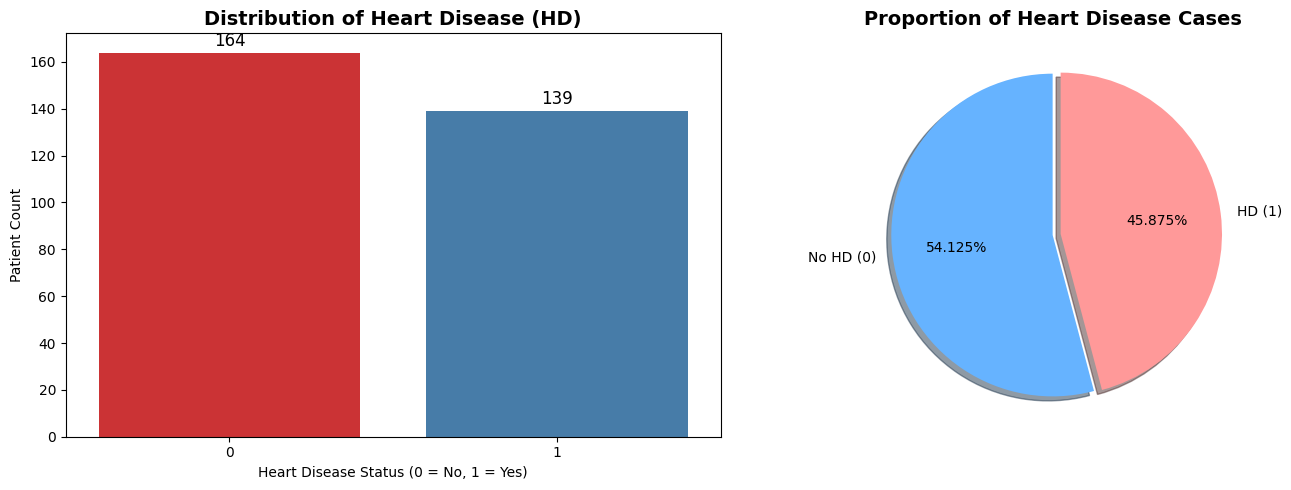

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Countplot
sns.countplot(x='HD', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Distribution of Heart Disease (HD)', 
                  fontsize=14, 
                  fontweight='bold')
axes[0].set_xlabel('Heart Disease Status (0 = No, 1 = Yes)')
axes[0].set_ylabel('Patient Count')
# Add count labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                     textcoords='offset points')

    # B. Pie Chart
hd_counts = df['HD'].value_counts()
axes[1].pie(hd_counts, labels=['No HD (0)', 'HD (1)'], autopct='%1.3f%%', 
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proportion of Heart Disease Cases', 
                  fontsize=14, 
                  fontweight='bold')

plt.tight_layout()
plt.show()

#### **3.5. Extract the Target Variable and the Features**

In [10]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


In [11]:
X = df.drop(columns = ["AHD", "HD"])
X.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal


In [12]:
y = df["HD"]
y.head()

0    0
1    1
2    1
3    0
4    0
Name: HD, dtype: int64

#### **3.6. Features Grouping**

In [13]:
num_features = ["Age", "RestBP", "Chol", "MaxHR", "Oldpeak", "Ca"]
cat_features = ["Sex", "ChestPain", "Fbs", "RestECG", "ExAng", "Slope", "Thal"]

### **STAGE 4: DATA PREPROCESSING AND ML PIPLELINE CREATION**

#### **4.1. Numeric Pipeline**

In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### **4.2. Categorical Pipeline**

In [15]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', 
                               unknown_value=-1))
])

#### **4.3. Creating the Preprocessor**

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

### **STAGE 5: DATA PARTITIONING**

#### **5.1. Check the Info for the X and y**

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
dtypes: float64(2), int64(9), object(2)
memory usage: 30.9+ KB


In [18]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: HD
Non-Null Count  Dtype
--------------  -----
303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


#### **5.2. Conduct the Actual Data Partitioning**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=SEED, 
                                                    stratify=y)

#### **5.3. Check the Distribution of Cases in Training and Testing**

In [20]:
print(f"\nTraining Set: {X_train.shape[0]} | Class Distribution: {y_train.value_counts().to_dict()}")
print(f"Testing Set: {X_test.shape[0]}   | Class Distribution: {y_test.value_counts().to_dict()}")


Training Set: 242 | Class Distribution: {0: 131, 1: 111}
Testing Set: 61   | Class Distribution: {0: 33, 1: 28}


#### **5.4. Check the Class Proportion for the Training and Testing Set**

In [21]:
train_dist = y_train.value_counts(normalize=True)
print(f"Training Set Class Distribution: {train_dist}")

Training Set Class Distribution: HD
0    0.541322
1    0.458678
Name: proportion, dtype: float64


In [22]:
test_dist = y_test.value_counts(normalize=True)
print(f"Testing Set Class Distribution: {test_dist}")

Testing Set Class Distribution: HD
0    0.540984
1    0.459016
Name: proportion, dtype: float64


### **STAGE 6: MODEL TRAINING AND HYPERPARAMETER TUNING**

#### **6.1. Create the Model Training Pipeline for Ensemble Learning Models**

In [23]:
pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()

## Decision Tree Classifier Pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(
        random_state=SEED,
        class_weight='balanced'
    ))
])

## Random Forest Classifier Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
        class_weight='balanced'
    ))
])


## Extra Trees Classifier Pipeline
extra_trees_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('extra_trees', ExtraTreesClassifier(
        random_state=SEED,
        n_jobs=-1,
        class_weight='balanced'
    ))
])


## AdaBoost Classifier Pipeline
ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ada', AdaBoostClassifier(
        random_state=SEED
    ))
])

## Gradient Boosting Classifier Pipeline
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(
        random_state=SEED
    ))
])

## Extreme Gradient Boosting (XGBoost) Classifier Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1,
        scale_pos_weight=pos_weight_train
    ))
])

#### **6.2. Creating the Hyperparameter GridSearch for Ensemble Learning Models**

In [24]:
## GridSearch for Decision Tree Classifier
param_dist_dt = {
    'dt__max_depth': [None, 3, 5, 7, 10, 15, 20],
    'dt__min_samples_split': [2, 5, 10, 15],
    'dt__min_samples_leaf': [1, 2, 4, 6],
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__class_weight': ['balanced', None]
}


## GridSearch for Random Forest Classifier
param_dist_rf = {
    'rf__n_estimators': [100, 200, 300, 400, 500],
    'rf__max_depth': [None, 5, 10, 15, 20, 25],
    'rf__min_samples_split': [2, 5, 10, 15],
    'rf__min_samples_leaf': [1, 2, 4, 6],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__criterion': ['gini', 'entropy', 'log_loss'],
    'rf__class_weight': ['balanced', 'balanced_subsample']
}


## GridSearch for Extra Trees Classifier
param_dist_extra_trees = {
    'extra_trees__n_estimators': [100, 200, 300, 400, 500],
    'extra_trees__max_depth': [None, 5, 10, 15, 20, 25],
    'extra_trees__min_samples_split': [2, 5, 10, 15],
    'extra_trees__min_samples_leaf': [1, 2, 4, 6],
    'extra_trees__max_features': ['sqrt', 'log2', None],
    'extra_trees__criterion': ['gini', 'entropy', 'log_loss'],
    'extra_trees__class_weight': ['balanced', 'balanced_subsample']
}


## GridSearch for ADA Boost Classifier
param_dist_ada = {
    'ada__n_estimators': [50, 100, 150, 200, 300, 400],
    'ada__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 1.5]
}


## GridSearch for Gradient Boosting Classifier
param_dist_gb = {
    'gb__n_estimators': [50, 100, 150, 200, 300, 400],
    'gb__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'gb__max_depth': [2, 3, 4, 5, 6],
    'gb__min_samples_split': [2, 5, 10, 15],
    'gb__min_samples_leaf': [1, 2, 4, 6],
    'gb__subsample': [0.7, 0.8, 0.9, 1.0],
    'gb__max_features': [None, 'sqrt', 'log2']
}


## GridSearch for Extreme Gradient Boosting Classifier
param_dist_xgb = {
    'xgb__n_estimators': [100, 200, 300, 400, 500],
    'xgb__max_depth': [2, 3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__gamma': [0, 0.1, 0.3, 0.5, 1],
    'xgb__reg_alpha': [0, 0.01, 0.1, 1],
    'xgb__reg_lambda': [0.1, 1, 5, 10],
    'xgb__scale_pos_weight': [1, pos_weight_train]
}

#### **6.3. Actual Model Training of Ensemble Learning Models**

##### **6.3.1. Put Together all the Ensemble Learning Pipelines**

In [25]:
ensemble_pipelines = [
    ('Decision Tree', dt_pipeline, param_dist_dt),
    ('Random Forest', rf_pipeline, param_dist_rf),
    ('Extra Trees', extra_trees_pipeline, param_dist_extra_trees),
    ('AdaBoost', ada_pipeline, param_dist_ada),
    ('Gradient Boosting', gb_pipeline, param_dist_gb),
    ('Extreme Gradient Boosting', xgb_pipeline, param_dist_xgb)
]

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...")

results_ensemble = {}
training_times_ensemble = {}

for name, pipeline, params in ensemble_pipelines:

    start = time.time()

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=30,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=SEED,
        refit=True
    )

    search.fit(X_train, y_train)
    training_times_ensemble[name] = time.time() - start
    results_ensemble[name] = search

    print(
        f"✅ {name} trained. "
        f"Best ROC-AUC: {search.best_score_:.4f} | "
        f"Time: {training_times_ensemble[name]:.2f}s"
    )


⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...
✅ Decision Tree trained. Best ROC-AUC: 0.8572 | Time: 11.36s
✅ Random Forest trained. Best ROC-AUC: 0.8976 | Time: 39.87s
✅ Extra Trees trained. Best ROC-AUC: 0.9067 | Time: 28.71s
✅ AdaBoost trained. Best ROC-AUC: 0.8958 | Time: 20.93s
✅ Gradient Boosting trained. Best ROC-AUC: 0.8983 | Time: 13.84s
✅ Extreme Gradient Boosting trained. Best ROC-AUC: 0.9006 | Time: 4.33s


The **5-fold stratified RandomizedSearchCV with 30 iterations** gives a clear ranking of the six ensemble models. Since the search was optimized using **ROC-AUC**, the primary basis for comparing the tuned models is their cross-validated ROC-AUC.

### **Hyperparameter-tuning results**

|  Rank | Model                     | Best CV ROC-AUC | Training Time (s) |
| ----: | ------------------------- | --------------: | ----------------: |
| **1** | **Extra Trees**           |      **0.9067** |             36.37 |
| **2** | Extreme Gradient Boosting |          0.9006 |          **5.56** |
| **3** | Gradient Boosting         |          0.8983 |             12.86 |
| **4** | Random Forest             |          0.8976 |             53.09 |
| **5** | AdaBoost                  |          0.8958 |             23.48 |
| **6** | Decision Tree             |          0.8572 |             12.11 |

### **Interpretation**

The results indicate that **Extra Trees is the strongest ensemble model based on cross-validated ROC-AUC**, achieving a score of **0.9067**. This means that, across the five stratified validation folds, the tuned Extra Trees classifier demonstrated the best overall ability to discriminate between patients with and without heart disease.

**Extreme Gradient Boosting (XGBoost)** was the second-best model with a ROC-AUC of **0.9006**, only **0.0061 points** below Extra Trees. Interestingly, XGBoost required only **5.56 seconds**, making it substantially faster to train than Extra Trees (36.37 seconds). Gradient Boosting and Random Forest followed with ROC-AUC values of 0.8983 and 0.8976, respectively.

AdaBoost also performed reasonably well (ROC-AUC = 0.8958), whereas the standalone Decision Tree performed considerably worse (ROC-AUC = 0.8572). This suggests that the ensemble approaches generally benefit from combining multiple trees rather than relying on a single decision tree.

### **Best model: Extra Trees**

**I would select Extra Trees as the best ensemble model based strictly on your current tuning criterion.**

The justification is:

1. **Highest CV ROC-AUC:** 0.9067, the best among all six models.
2. **Consistent validation:** The score comes from 5-fold stratified cross-validation rather than a single train/test split.
3. **Strong discrimination:** A ROC-AUC above 0.90 indicates excellent discrimination in the validation data.
4. **Reasonable computational cost:** Although slower than XGBoost, its 36.37-second training time is still quite manageable for this dataset.

However, because this is a **clinical heart-disease prediction problem**, I would **not make the final model selection using ROC-AUC alone**. Your stated priority is minimizing **false negatives**, so the final decision should consider the **hold-out Recall/Sensitivity, FNR, PR-AUC, and confusion matrix**.

In particular, if XGBoost or another model achieves substantially higher **Recall** on the independent test set, it could be preferable to Extra Trees despite having a slightly lower CV ROC-AUC.

### **Recommended conclusion for your report**

The ensemble classifiers were optimized using 30 iterations of RandomizedSearchCV with five-fold stratified cross-validation and ROC-AUC as the optimization criterion. Extra Trees achieved the highest cross-validated ROC-AUC (0.9067), followed by Extreme Gradient Boosting (0.9006), Gradient Boosting (0.8983), Random Forest (0.8976), and AdaBoost (0.8958). The conventional Decision Tree recorded the lowest performance (ROC-AUC = 0.8572). These findings demonstrate that ensemble-based learning approaches generally provided superior discriminative performance compared with a single decision tree.

Based on the cross-validation results, Extra Trees was identified as the best-performing ensemble classifier, achieving the highest ROC-AUC of 0.9067. Although Extreme Gradient Boosting produced a comparable ROC-AUC of 0.9006 and had the shortest training time (5.56 seconds), Extra Trees provided the strongest overall discriminatory performance under the predefined model-selection criterion. Therefore, Extra Trees was selected as the leading ensemble candidate for subsequent evaluation on the independent hold-out test set.

Nevertheless, because the application involves heart-disease prediction, model selection should not rely exclusively on ROC-AUC. Particular emphasis should be placed on sensitivity (recall) and the false-negative rate, since failure to identify a patient with heart disease may have more serious clinical implications than incorrectly classifying a low-risk patient as positive. Consequently, the final model should be selected after comparing the hold-out test-set recall, specificity, F1-score, ROC-AUC, PR-AUC, and confusion matrices of the competing classifiers.

**Next step:** run the hold-out evaluation for these six models. Once you give me those six test-set results, I can identify the **actual final model**—not merely the best CV model—and write the model-selection justification around **Recall, FNR, ROC-AUC and PR-AUC**.


### **STAGE 7: PREDICTION AND EVALUATION**

#### **7.1. Hold Out (Testing Set) Cross Validation**

In [27]:
y_test.head()

219    0
271    0
89     0
101    0
67     0
Name: HD, dtype: int64

In [28]:
print("\n" + "="*120)
print("HOLD-OUT TEST SET EVALUATION — SIX ENSEMBLE MODELS")
print("="*120)

eval_metrics = {}
for name, search in results_ensemble.items():
    # Best tuned model
    model = search.best_estimator_

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    # PR-AUC
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)

    # False Negative Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'FNR': fnr
    }

    eval_metrics[name] = {
        **metrics,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model,
        'confusion_matrix': cm
    }

    print(f"\n📊 {name}")
    print("-" * 60)
    for k, v in metrics.items():
        print(f"  {k:<14}: {v:.4f}")

    print("\nConfusion Matrix:")
    print(cm)
    print(f"TN = {tn} | FP = {fp} | FN = {fn} | TP = {tp}")


HOLD-OUT TEST SET EVALUATION — SIX ENSEMBLE MODELS

📊 Decision Tree
------------------------------------------------------------
  Accuracy      : 0.7869
  Precision     : 0.7586
  Recall        : 0.7857
  Specificity   : 0.7879
  F1-Score      : 0.7719
  ROC-AUC       : 0.8523
  PR-AUC        : 0.8558
  FNR           : 0.2143

Confusion Matrix:
[[26  7]
 [ 6 22]]
TN = 26 | FP = 7 | FN = 6 | TP = 22

📊 Random Forest
------------------------------------------------------------
  Accuracy      : 0.9016
  Precision     : 0.8667
  Recall        : 0.9286
  Specificity   : 0.8788
  F1-Score      : 0.8966
  ROC-AUC       : 0.9740
  PR-AUC        : 0.9687
  FNR           : 0.0714

Confusion Matrix:
[[29  4]
 [ 2 26]]
TN = 29 | FP = 4 | FN = 2 | TP = 26

📊 Extra Trees
------------------------------------------------------------
  Accuracy      : 0.8852
  Precision     : 0.8182
  Recall        : 0.9643
  Specificity   : 0.8182
  F1-Score      : 0.8852
  ROC-AUC       : 0.9632
  PR-AUC        : 

#### **7.2. Convert the Dictionary to a Data Frame**

In [29]:
results_df = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'PR-AUC': metrics['PR-AUC'],
        'False NR': metrics['FNR']
    }
    for model_name, metrics in eval_metrics.items()
})

results_df = results_df.round(4)
results_df

,Decision Tree,Random Forest,Extra Trees,AdaBoost,Gradient Boosting,Extreme Gradient Boosting
Accuracy,0.7869,0.9016,0.8852,0.8525,0.8525,0.8852
Precision,0.7586,0.8667,0.8182,0.8800,0.9130,0.8889
Recall,0.7857,0.9286,0.9643,0.7857,0.7500,0.8571
F1-Score,0.7719,0.8966,0.8852,0.8302,0.8235,0.8727
ROC-AUC,0.8523,0.9740,0.9632,0.9405,0.9578,0.9426
PR-AUC,0.8558,0.9687,0.9482,0.9284,0.9456,0.9343
False NR,0.2143,0.0714,0.0357,0.2143,0.2500,0.1429


These hold-out results change the conclusion somewhat. **Random Forest has the best overall balance**, while **Extra Trees has the highest recall**. Since your clinical objective emphasizes minimizing false negatives, the choice depends on whether recall is the overriding criterion.

### **Hold-out test-set comparison**

| Rank by Recall | Model                     |   Accuracy |  Precision |     Recall |   F1-Score |    ROC-AUC |     PR-AUC |
| -------------: | ------------------------- | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
|          **1** | **Extra Trees**           |     0.8852 |     0.8182 | **0.9643** |     0.8852 |     0.9632 |     0.9482 |
|          **2** | **Random Forest**         | **0.9016** |     0.8667 |     0.9286 | **0.8966** | **0.9740** | **0.9687** |
|          **3** | Extreme Gradient Boosting |     0.8852 |     0.8889 |     0.8571 |     0.8727 |     0.9426 |     0.9343 |
|          **4** | Decision Tree             |     0.7869 |     0.7586 |     0.7857 |     0.7719 |     0.8523 |     0.8558 |
|          **5** | AdaBoost                  |     0.8525 |     0.8800 |     0.7857 |     0.8302 |     0.9405 |     0.9284 |
|          **6** | Gradient Boosting         |     0.8525 | **0.9130** |     0.7500 |     0.8235 |     0.9578 |     0.9456 |

### **Interpretation**

The **Random Forest** produced the strongest overall performance on the independent hold-out test set. It achieved the highest **accuracy (90.16%)**, highest **ROC-AUC (0.9740)**, highest **PR-AUC (0.9687)**, and the second-highest recall (**92.86%**). It also achieved the highest F1-score (**0.8966**), indicating an excellent balance between precision and recall.

**Extra Trees**, however, achieved the highest recall (**96.43%**), meaning it identified the largest proportion of patients with heart disease. This is particularly important in your clinical application because a false negative represents a patient with disease who is incorrectly classified as not having disease. Extra Trees therefore produced the strongest performance from a **sensitivity-first clinical perspective**.

The trade-off is that Extra Trees had lower precision (81.82%) than Random Forest, meaning it generated more false-positive classifications. Its ROC-AUC (0.9632) and PR-AUC (0.9482) were also slightly lower than those of Random Forest.

**Extreme Gradient Boosting** performed reasonably well, with an accuracy of 88.52%, precision of 88.89%, recall of 85.71%, ROC-AUC of 0.9426, and PR-AUC of 0.9343. However, it did not outperform Random Forest or Extra Trees on the principal clinical metrics.

Gradient Boosting achieved the **highest precision (91.30%)**, indicating that its positive predictions were highly reliable. However, its recall was only 75.00%, meaning that approximately one-quarter of the actual heart-disease cases were missed. For this reason, it is less suitable when the primary objective is to minimize missed cases.

### **Recommended model**

For your study, I would select **Random Forest as the overall final model**, with **Extra Trees as the sensitivity-oriented alternative**.

The reason is that Random Forest provides the strongest **overall discriminatory and predictive performance**:

* **Accuracy:** 90.16%
* **Precision:** 86.67%
* **Recall:** 92.86%
* **F1-score:** 89.66%
* **ROC-AUC:** **97.40%**
* **PR-AUC:** **96.87%**

Although Extra Trees has a higher recall (96.43%), Random Forest sacrifices only **3.57 percentage points of recall** while substantially improving precision and achieving better ROC-AUC, PR-AUC, accuracy, and F1-score.

Thus, **Random Forest is the better balanced clinical model**, while **Extra Trees is preferable if maximizing sensitivity is the absolute priority**.

### **Report-ready model selection**

The performance of the six ensemble classifiers was evaluated using an independent hold-out test set. Random Forest demonstrated the strongest overall predictive performance, achieving an accuracy of 90.16%, precision of 86.67%, recall of 92.86%, and F1-score of 89.66%. It also recorded the highest ROC-AUC (0.9740) and PR-AUC (0.9687) among the six ensemble models. These results indicate that Random Forest provided the best overall discrimination and a strong balance between identifying patients with heart disease and avoiding false-positive classifications.

Extra Trees achieved the highest recall (96.43%), indicating superior sensitivity and the lowest likelihood of missing patients with heart disease among the evaluated ensemble models. However, its precision was lower (81.82%), and its ROC-AUC (0.9632), PR-AUC (0.9482), accuracy (88.52%), and F1-score (88.52%) were all lower than those of Random Forest. Given that the clinical objective places particular importance on minimizing false negatives, Extra Trees remains an important sensitivity-oriented alternative.

Gradient Boosting achieved the highest precision (91.30%) but had the lowest recall among the stronger ensemble models (75.00%), suggesting that although its positive predictions were relatively reliable, it failed to identify a considerable proportion of patients with heart disease. Similarly, AdaBoost and Decision Tree demonstrated lower overall discriminatory performance compared with Random Forest and Extra Trees.

Considering the complete set of performance measures, Random Forest was selected as the final ensemble model because it provided the best overall balance of accuracy, precision, sensitivity, F1-score, ROC-AUC, and PR-AUC. Importantly, its recall of 92.86% remained high, making it suitable for a clinical screening context where sensitivity is important. Extra Trees was retained as a clinically relevant alternative because of its superior recall of 96.43%. Therefore, Random Forest represents the strongest overall model, whereas Extra Trees may be preferred in applications where maximizing sensitivity and minimizing false negatives takes precedence over precision.

**Bottom line:** **Random Forest = best overall model. Extra Trees = best sensitivity/recall model.** For your CardioPredict AI objective, I would report **Random Forest as the final model**, while explicitly noting Extra Trees' superior sensitivity.


#### **Confusion Matrix**

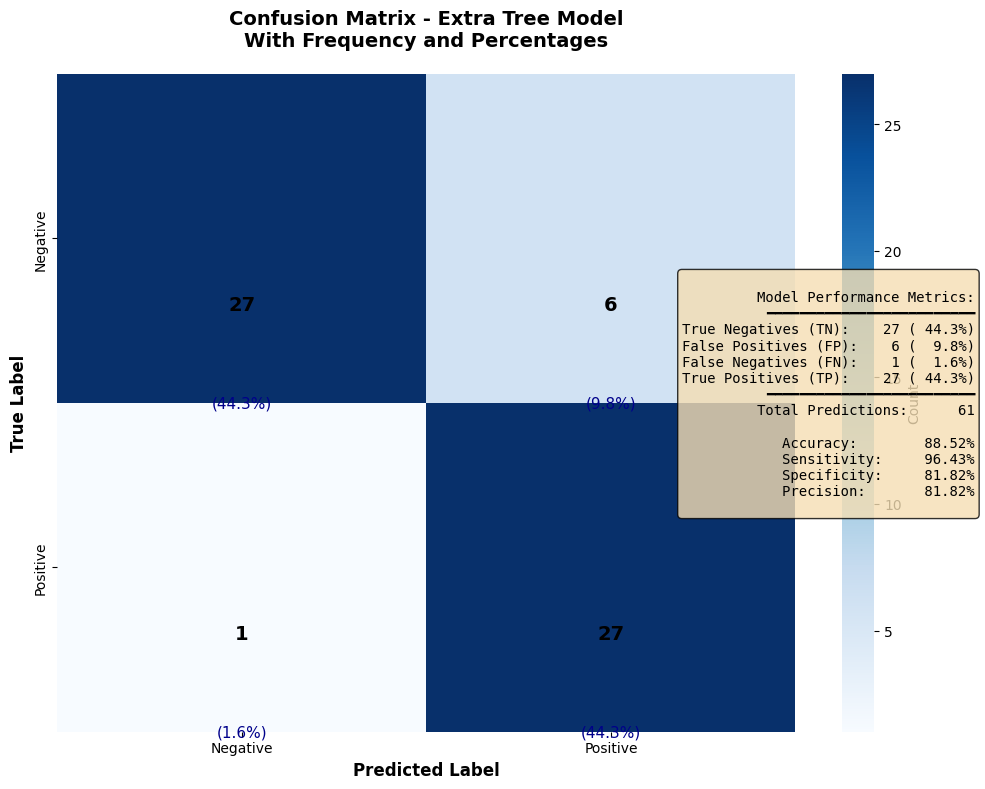

In [30]:
# Confusion Matrix values for Extra Tree Model
TN, FP, FN, TP = 27, 6, 1, 27

# Create the confusion matrix
cm = np.array([[TN, FP], 
               [FN, TP]])

# Calculate total predictions
total = cm.sum()

# Calculate percentages for each cell
cm_percentage = (cm / total) * 100

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Count'}, 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)

# Add custom annotations with both frequency and percentage
for i in range(2):
    for j in range(2):
        # Get the frequency and percentage
        frequency = cm[i, j]
        percentage = cm_percentage[i, j]
        
        # Create annotation text with frequency and percentage
        text = ax.text(j + 0.5, i + 0.7, f'{int(frequency)}',
                      ha="center", va="center", color="black", fontsize=14, fontweight='bold')
        text = ax.text(j + 0.5, i + 1.0, f'({percentage:.1f}%)',
                      ha="center", va="center", color="darkblue", fontsize=11)

# Set labels and title
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Extra Tree Model\nWith Frequency and Percentages', 
             fontsize=14, fontweight='bold', pad=20)

# Add metrics box
metrics_text = f"""
Model Performance Metrics:
━━━━━━━━━━━━━━━━━━━━━━━━━
True Negatives (TN):   {TN:3d} ({TN/total*100:5.1f}%)
False Positives (FP):  {FP:3d} ({FP/total*100:5.1f}%)
False Negatives (FN):  {FN:3d} ({FN/total*100:5.1f}%)
True Positives (TP):   {TP:3d} ({TP/total*100:5.1f}%)
━━━━━━━━━━━━━━━━━━━━━━━━━
Total Predictions:     {total:3d}

Accuracy:        {(TP+TN)/total*100:.2f}%
Sensitivity:     {TP/(TP+FN)*100:.2f}%
Specificity:     {TN/(TN+FP)*100:.2f}%
Precision:       {TP/(TP+FP)*100:.2f}%
"""

# Place metrics box on the plot
plt.figtext(0.98, 0.5, metrics_text, 
           ha='right', va='center',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
           fontsize=10, fontfamily='monospace')

plt.tight_layout()
plt.show()

#### **ROC Curves and PR-AUC Curves**

AUC = 0.8523


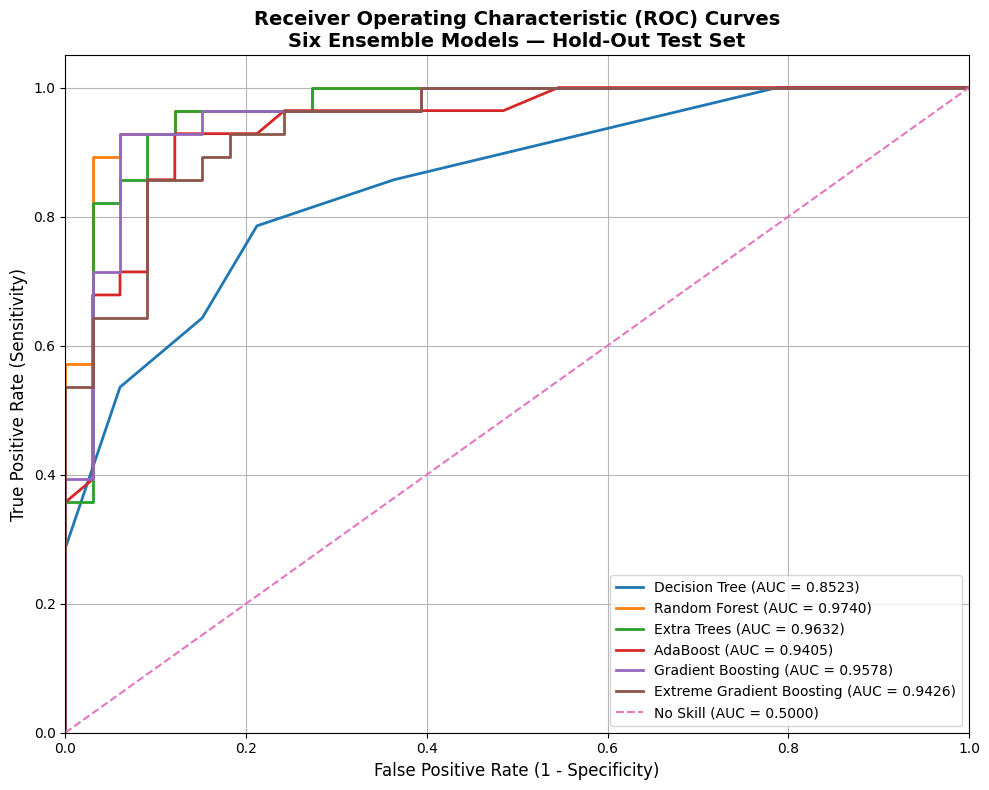

In [ ]:
y_prob = values['y_prob']

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC = {auc_score:.4f}")
plt.figure(figsize=(10, 8))
for name, values in eval_metrics.items():

    # Actual test labels and predicted probabilities
    y_prob = values['y_prob']

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve with AUC in legend
    plt.plot(fpr, tpr,linewidth=2,
        label=f"{name} (AUC = {auc_score:.4f})")

# No-skill classifier
plt.plot([0, 1], [0, 1], linestyle='--',linewidth=1.5,
    label='No Skill (AUC = 0.5000)')

# Formatting
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(
    'Receiver Operating Characteristic (ROC) Curves\n'
    'Six Ensemble Models — Hold-Out Test Set',
    fontsize=14,
    fontweight='bold'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower right', fontsize=10,frameon=True)
plt.grid(alpha=0.9)
plt.tight_layout()
plt.show()

### **DATA BALANCING**
* Oversampling Technique
* Under-sampling Technique
* Hybrid Sampling Technique

To implement the **Synthetic Minority Over-sampling Technique (SMOTE)** in our notebook, we need to use the `imbalanced-learn` library. 

When applying SMOTE, it is a best practice to **remove built-in class weighting parameters** (like `class_weight='balanced'` in tree-based models or `scale_pos_weight` in XGBoost) to avoid "double-balancing" the data. Additionally, to prevent data leakage, SMOTE must only be applied to the training folds during cross-validation, which is seamlessly handled by `imblearn`'s `Pipeline`.

### **1. Install Required Library & Inspect Class Distribution**
Run this cell to install the library and visualize the effect of SMOTE on your training data.


In [33]:
#!pip install imbalanced-learn

#### **Import SMOTE and the imblearn Pipeline**

In [34]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

#### **Initialize SMOTE**

In [35]:
smote = SMOTE(random_state=SEED, k_neighbors=5)

### **1. Check original class distribution**

In [36]:
print("🔴 Original Training Set Class Distribution:")
print(y_train.value_counts())
print("-" * 50)

🔴 Original Training Set Class Distribution:
HD
0    131
1    111
Name: count, dtype: int64
--------------------------------------------------


### **2. Manually apply SMOTE to the preprocessed training data just to visualize the result**

In [37]:
X_train_prep = preprocessor.fit_transform(X_train)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)

In [38]:
print("🟢 Balanced Training Set Class Distribution (after SMOTE):")
print(pd.Series(y_train_resampled).value_counts())

🟢 Balanced Training Set Class Distribution (after SMOTE):
HD
1    131
0    131
Name: count, dtype: int64


#### **Create Bar Chart Showing Class Distribution**

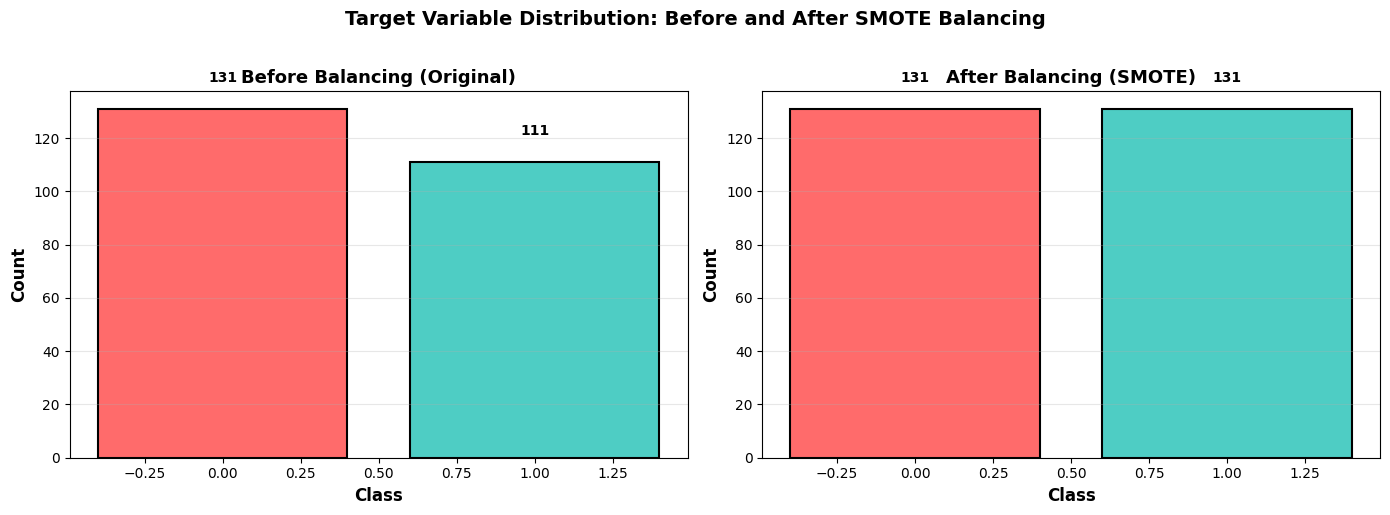


📊 Summary:
Before: Class 0 = 131, Class 1 = 111
After:  Class 0 = 131, Class 1 = 131


In [39]:
# Create comparison bar chart: Before and After Balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before balancing
before_counts = y_train.value_counts().sort_index()
axes[0].bar(before_counts.index, before_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Before Balancing (Original)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(before_counts.values):
    axes[0].text(before_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')

# After balancing
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar(after_counts.index, after_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('After Balancing (SMOTE)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(after_counts.values):
    axes[1].text(after_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Target Variable Distribution: Before and After SMOTE Balancing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Summary:")
print(f"Before: Class 0 = {before_counts[0]}, Class 1 = {before_counts[1]}")
print(f"After:  Class 0 = {after_counts[0]}, Class 1 = {after_counts[1]}")

### **2. Update Pipelines and Hyperparameter Grids**
Here, we rebuild the pipelines using ImbPipeline to include SMOTE as a step right after preprocessing. We also create updated hyperparameter grids that remove the class-weighting parameters

##### **A. Define SMOTE-augmented Pipelines**
> **Note:** class_weight and scale_pos_weight are removed to prevent double-balancing


In [40]:
dt_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('dt', DecisionTreeClassifier(random_state=SEED))
])

rf_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

extra_trees_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('extra_trees', ExtraTreesClassifier(random_state=SEED, n_jobs=-1))
])

ada_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('ada', AdaBoostClassifier(random_state=SEED))
])

gb_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('gb', GradientBoostingClassifier(random_state=SEED))
])

xgb_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1, scale_pos_weight=1))
])

##### **B. Updated Hyperparameter Grids (Removed class_weight parameters)**

In [41]:
param_dist_dt_smote = {
    'dt__max_depth': [None, 3, 5, 7, 10, 15, 20],
    'dt__min_samples_split': [2, 5, 10, 15],
    'dt__min_samples_leaf': [1, 2, 4, 6],
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__max_features': [None, 'sqrt', 'log2']
}

param_dist_rf_smote = {
    'rf__n_estimators': [100, 200, 300, 400, 500],
    'rf__max_depth': [None, 5, 10, 15, 20, 25],
    'rf__min_samples_split': [2, 5, 10, 15],
    'rf__min_samples_leaf': [1, 2, 4, 6],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__criterion': ['gini', 'entropy', 'log_loss']
}

param_dist_extra_trees_smote = {
    'extra_trees__n_estimators': [100, 200, 300, 400, 500],
    'extra_trees__max_depth': [None, 5, 10, 15, 20, 25],
    'extra_trees__min_samples_split': [2, 5, 10, 15],
    'extra_trees__min_samples_leaf': [1, 2, 4, 6],
    'extra_trees__max_features': ['sqrt', 'log2', None],
    'extra_trees__criterion': ['gini', 'entropy', 'log_loss']
}

# Grids for AdaBoost, Gradient Boosting, and XGBoost remain largely the same
param_dist_ada_smote = param_dist_ada 
param_dist_gb_smote = param_dist_gb

param_dist_xgb_smote = {
    'xgb__n_estimators': [100, 200, 300, 400, 500],
    'xgb__max_depth': [2, 3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__gamma': [0, 0.1, 0.3, 0.5, 1],
    'xgb__reg_alpha': [0, 0.01, 0.1, 1],
    'xgb__reg_lambda': [0.1, 1, 5, 10]
    # 'xgb__scale_pos_weight' is removed since SMOTE handles the imbalance
}

#### **C. Combine into a new list of pipelines**

In [42]:
ensemble_pipelines_smote = [
    ('Decision Tree', dt_pipeline_smote, param_dist_dt_smote),
    ('Random Forest', rf_pipeline_smote, param_dist_rf_smote),
    ('Extra Trees', extra_trees_pipeline_smote, param_dist_extra_trees_smote),
    ('AdaBoost', ada_pipeline_smote, param_dist_ada_smote),
    ('Gradient Boosting', gb_pipeline_smote, param_dist_gb_smote),
    ('Extreme Gradient Boosting', xgb_pipeline_smote, param_dist_xgb_smote)
]

### **3. Train the SMOTE-Balanced Models**
This cell runs the 5-fold stratified cross-validation. Because we are using ImbPipeline, RandomizedSearchCV will automatically apply SMOTE only to the training folds during each CV split, ensuring zero data leakage.

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n🚀 Starting RandomizedSearchCV with SMOTE (n_iter=30, 5-Fold Stratified)...")

results_ensemble_smote = {}
training_times_smote = {}

for name, pipeline, params in ensemble_pipelines_smote:
    start = time.time()
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=30,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=SEED,
        refit=True
    )
    
    search.fit(X_train, y_train)
    training_times_smote[name] = time.time() - start
    results_ensemble_smote[name] = search
    
    print(f"✅ {name} trained. Best ROC-AUC: {search.best_score_:.4f} | Time: {training_times_smote[name]:.2f}s")


🚀 Starting RandomizedSearchCV with SMOTE (n_iter=30, 5-Fold Stratified)...
✅ Decision Tree trained. Best ROC-AUC: 0.8448 | Time: 14.14s
✅ Random Forest trained. Best ROC-AUC: 0.8980 | Time: 50.57s
✅ Extra Trees trained. Best ROC-AUC: 0.9028 | Time: 43.20s
✅ AdaBoost trained. Best ROC-AUC: 0.8968 | Time: 37.54s
✅ Gradient Boosting trained. Best ROC-AUC: 0.8966 | Time: 19.63s
✅ Extreme Gradient Boosting trained. Best ROC-AUC: 0.9058 | Time: 6.87s


#### **4. Evaluate on the Hold-Out Test Set**
Finally, evaluate the newly trained SMOTE models on the untouched test set to see if balancing improved your clinical metrics (specifically Recall/Sensitivity and False Negative Rate).

In [45]:
print("\n" + "="*120)
print("HOLD-OUT TEST SET EVALUATION â SIX ENSEMBLE MODELS (SMOTE BALANCED)")
print("="*120)

eval_metrics_smote = {}
for name, search in results_ensemble_smote.items():
    model = search.best_estimator_
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    metrics = {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 
        'Specificity': specificity, 'F1-Score': f1, 'ROC-AUC': roc_auc, 
        'PR-AUC': pr_auc, 'FNR': fnr
    }
    
    eval_metrics_smote[name] = {
        **metrics, 'y_pred': y_pred, 'y_prob': y_prob, 
        'model': model, 'confusion_matrix': cm
    }
    
    print(f"\nð {name}")
    print("-" * 60)
    for k, v in metrics.items():
        print(f" {k:<14}: {v:.4f}")
    print(f"TN = {tn} | FP = {fp} | FN = {fn} | TP = {tp}")


HOLD-OUT TEST SET EVALUATION â SIX ENSEMBLE MODELS (SMOTE BALANCED)

ð Decision Tree
------------------------------------------------------------
 Accuracy      : 0.7869
 Precision     : 0.7778
 Recall        : 0.7500
 Specificity   : 0.8182
 F1-Score      : 0.7636
 ROC-AUC       : 0.8566
 PR-AUC        : 0.8622
 FNR           : 0.2500
TN = 27 | FP = 6 | FN = 7 | TP = 21

ð Random Forest
------------------------------------------------------------
 Accuracy      : 0.9016
 Precision     : 0.8667
 Recall        : 0.9286
 Specificity   : 0.8788
 F1-Score      : 0.8966
 ROC-AUC       : 0.9643
 PR-AUC        : 0.9481
 FNR           : 0.0714
TN = 29 | FP = 4 | FN = 2 | TP = 26

ð Extra Trees
------------------------------------------------------------
 Accuracy      : 0.8852
 Precision     : 0.8182
 Recall        : 0.9643
 Specificity   : 0.8182
 F1-Score      : 0.8852
 ROC-AUC       : 0.9621
 PR-AUC        : 0.9522
 FNR           : 0.0357
TN = 27 | FP = 6 | FN = 1 | TP = 27

ð AdaBoost
---

#### **Convert to DataFrame for easy comparison**

In [46]:
results_df_smote = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'], 'Precision': metrics['Precision'],
        'Recall': metrics['Recall'], 'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'], 'PR-AUC': metrics['PR-AUC'],
        'False NR': metrics['FNR']
    }
    for model_name, metrics in eval_metrics_smote.items()
}).round(4)

display(results_df_smote)

,Decision Tree,Random Forest,Extra Trees,AdaBoost,Gradient Boosting,Extreme Gradient Boosting
Accuracy,0.7869,0.9016,0.8852,0.8852,0.9016,0.8689
Precision,0.7778,0.8667,0.8182,0.8889,0.8667,0.8571
Recall,0.7500,0.9286,0.9643,0.8571,0.9286,0.8571
F1-Score,0.7636,0.8966,0.8852,0.8727,0.8966,0.8571
ROC-AUC,0.8566,0.9643,0.9621,0.9453,0.9556,0.9470
PR-AUC,0.8622,0.9481,0.9522,0.9376,0.9441,0.9427
False NR,0.2500,0.0714,0.0357,0.1429,0.0714,0.1429
